In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set dataset path
DATA_DIR = "/content/drive/MyDrive/project/Metal Surface Defects Data/Metal Surface Defects Data"

# Output folder for saving figures and models
import os
OUTPUTS = "/content/outputs"
os.makedirs(OUTPUTS, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUTS:", OUTPUTS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/project/Metal Surface Defects Data/Metal Surface Defects Data
OUTPUTS: /content/outputs


In [ ]:
import os

def inspect_data(data_dir):
    print("Root directory:", data_dir)
    for split in sorted(os.listdir(data_dir)):
        spath = os.path.join(data_dir, split)
        if os.path.isdir(spath):
            print(f"\n=== {split.upper()} ===")
            for cls in sorted(os.listdir(spath)):
                cls_path = os.path.join(spath, cls)
                if os.path.isdir(cls_path):
                    print(f"{cls:20s} → {len(os.listdir(cls_path))} images")

inspect_data(DATA_DIR)


Root directory: /content/drive/MyDrive/project/Metal Surface Defects Data/Metal Surface Defects Data

=== TEST ===
Crazing              → 12 images
Inclusion            → 12 images
Patches              → 12 images
Pitted               → 12 images
Rolled               → 12 images
Scratches            → 12 images

=== TRAIN ===
Crazing              → 276 images
Inclusion            → 276 images
Patches              → 276 images
Pitted               → 276 images
Rolled               → 276 images
Scratches            → 276 images

=== VALID ===
Crazing              → 12 images
Inclusion            → 12 images
Patches              → 12 images
Pitted               → 12 images
Rolled               → 12 images
Scratches            → 12 images


In [ ]:
import os

# Remove Thumbs.db if present
thumbs_path = os.path.join(DATA_DIR, "Thumbs.db")
if os.path.exists(thumbs_path):
    os.remove(thumbs_path)
    print("Removed Thumbs.db file")

# Recheck dataset structure
inspect_data(DATA_DIR)


Root directory: /content/drive/MyDrive/project/Metal Surface Defects Data/Metal Surface Defects Data

=== TEST ===
Crazing              → 12 images
Inclusion            → 12 images
Patches              → 12 images
Pitted               → 12 images
Rolled               → 12 images
Scratches            → 12 images

=== TRAIN ===
Crazing              → 276 images
Inclusion            → 276 images
Patches              → 276 images
Pitted               → 276 images
Rolled               → 276 images
Scratches            → 276 images

=== VALID ===
Crazing              → 12 images
Inclusion            → 12 images
Patches              → 12 images
Pitted               → 12 images
Rolled               → 12 images
Scratches            → 12 images


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Normalization layer to scale pixel values 0–255 → 0–1
normalization_layer = layers.Rescaling(1./255)


In [ ]:
import tensorflow as tf
import os

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

# Define paths
DATA_DIR = "/content/drive/MyDrive/project/Metal Surface Defects Data/Metal Surface Defects Data"
train_path = os.path.join(DATA_DIR, "train")
valid_path = os.path.join(DATA_DIR, "valid")
test_path  = os.path.join(DATA_DIR, "test")

# Load datasets (before prefetch)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',   # ✅ CHANGED: use RGB instead of grayscale
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',   # ✅ CHANGED
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',   # ✅ CHANGED
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)


# ✅ Get class names BEFORE prefetching
class_names = train_ds.class_names
num_classes = len(class_names)
print("✅ Classes detected:", class_names)

# Now prefetch safely
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 1656 files belonging to 6 classes.
Found 72 files belonging to 6 classes.
Found 72 files belonging to 6 classes.
✅ Classes detected: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

# 🔹 Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
])

# 🔹 Build Improved Model
def build_improved_model(input_shape=(128,128,3), num_classes=6):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model


# 🔹 Initialize and compile
improved_model = build_improved_model(input_shape=(128,128,3), num_classes=num_classes)

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()


# 🔹 Set up output folder
OUTPUTS = "/content/outputs"
os.makedirs(OUTPUTS, exist_ok=True)


# 🔹 Callbacks (EarlyStopping + Save Best Model + Reduce LR)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(OUTPUTS, "improved_best.h5"),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]


# 🔹 Train the model
EPOCHS = 25

history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,574 (32.37 MB)

 Trainable params: 8,484,614 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

...

52/52 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9062 - loss: 0.3072 - val_accuracy: 0.1944 - val_loss: 3.2334 - learning_rate: 0.0010
Epoch 10/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9148 - loss: 0.2858
Epoch 10: val_loss improved from 3.23335 to 1.62748, saving model to /content/outputs/improved_best.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9148 - loss: 0.2854 - val_accuracy: 0.5417 - val_loss: 1.6275 - learning_rate: 0.0010
Epoch 11/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9241 - loss: 0.2330
Epoch 11: val_loss improved from 1.62748 to 0.52655, saving model to /content/outputs/improved_best.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9240 - loss: 0.2330 - val_accuracy: 0.8333 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 12/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9203 - loss: 0.2300
Epoch 12: val_loss did not improve from 0.52655
52/52 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9205 - loss: 0.2296 - val_accuracy: 0.8056 - val_loss: 0.8074 - learning_rate: 0.0010
Epoch 13/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9211 - loss: 0.2135
Epoch 13: val_loss did not improve from 0.52655
52/52 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9211 - loss: 0.2133 - val_accuracy: 0.6389 - val_loss: 1.5132 - learning_rate: 0.0010
Epoch 14/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9248 - loss: 0.2195
Epoch 14: val_loss did not improve from 0.52655

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
52/52 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9248 - loss: 0.2196 - val_accuracy: 0.2500 - val_los

52/52 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9353 - loss: 0.1767 - val_accuracy: 0.7500 - val_loss: 0.4535 - learning_rate: 5.0000e-04
Epoch 16/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9422 - loss: 0.1571
Epoch 16: val_loss did not improve from 0.45352
52/52 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9422 - loss: 0.1570 - val_accuracy: 0.7361 - val_loss: 0.7444 - learning_rate: 5.0000e-04
Epoch 17/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9565 - loss: 0.1308
Epoch 17: val_loss improved from 0.45352 to 0.12751, saving model to /content/outputs/improved_best.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9565 - loss: 0.1307 - val_accuracy: 0.9444 - val_loss: 0.1275 - learning_rate: 5.0000e-04
Epoch 18/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9410 - loss: 0.1566
Epoch 18: val_loss did not improve from 0.12751
52/52 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9410 - loss: 0.1567 - val_accuracy: 0.8056 - val_loss: 0.7805 - learning_rate: 5.0000e-04
Epoch 19/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9539 - loss: 0.1179
Epoch 19: val_loss did not improve from 0.12751
52/52 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9540 - loss: 0.1179 - val_accuracy: 0.9444 - val_loss: 0.1279 - learning_rate: 5.0000e-04
Epoch 20/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9471 - loss: 0.1715
Epoch 20: val_loss did not improve from 0.12751

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
52/52 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9470 - loss: 0.1717 - val_accuracy: 0.43

In [ ]:
# Evaluate the improved model on unseen test data
test_loss, test_acc = improved_model.evaluate(test_ds)
print(f" Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step - accuracy: 0.9488 - loss: 0.1260
 Test Accuracy: 0.9444
 Test Loss: 0.1317


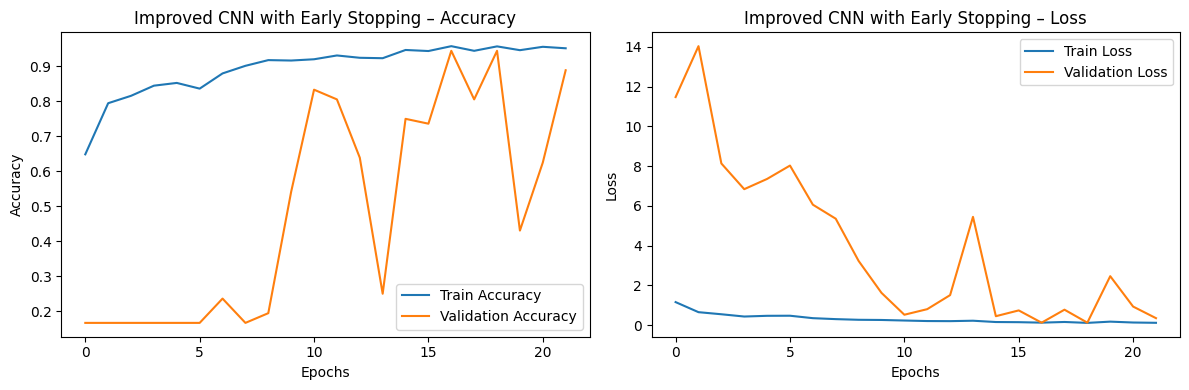

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title='Improved CNN'):
    plt.figure(figsize=(12,4))

    # Accuracy curve
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} – Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend()

    # Loss curve
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} – Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_improved, "Improved CNN with Early Stopping")


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect true and predicted labels
y_true, y_pred = [], []

for images, labels in test_ds.unbatch():
    preds = improved_model.predict(tf.expand_dims(images, axis=0), verbose=0)
    y_pred.append(np.argmax(preds))
    y_true.append(np.argmax(labels.numpy()))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


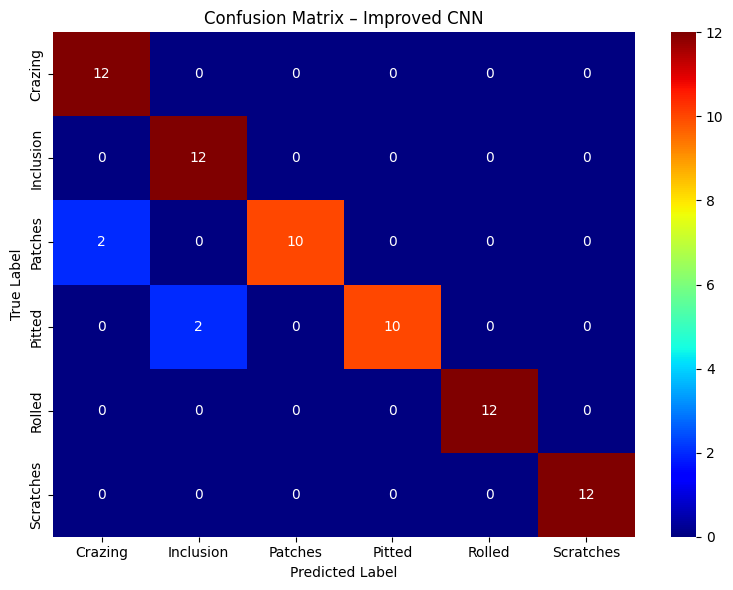

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='jet',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Improved CNN')
plt.tight_layout()

# Save confusion matrix for submission
plt.savefig(os.path.join(OUTPUTS, "confusion_matrix.png"))
plt.show()
